In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [170]:
# Read file (train & test for GARCH)

# Train set
df_train = pd.read_csv("dataset/GARCH/train_garch.csv")
df_train.drop(df_train.columns[0], axis=1, inplace=True)
df_train.set_index('period', inplace=True)

# Test set
df_test = pd.read_csv("dataset/GARCH/test_garch.csv")
df_test.drop(df_test.columns[0], axis=1, inplace=True)
df_test.set_index('period', inplace=True)

In [12]:
df_train.head()

,idr_usd
period,
2015-01-05,0.009211
2015-01-06,0.005439
2015-01-07,0.005878
2015-01-08,-0.000078
2015-01-09,-0.007216


In [13]:
df_train.tail()

,idr_usd
period,
2022-12-26,0.000705
2022-12-27,0.001985
2022-12-28,0.001470
2022-12-29,0.002805
2022-12-30,0.001782


In [14]:
df_test.tail()

,idr_usd
period,
2024-12-23,-0.000430
2024-12-24,-0.006845
2024-12-27,0.003027
2024-12-30,0.002649
2024-12-31,-0.005491


In [15]:
# Fit GARCH(1,1) di train + val

from arch import arch_model
## arch is used because it's widely used and supports a variety of types of ARCH/GARCH models
## including fit model, forecast volatility, and residual analysis.

am_in = arch_model(df_train, mean='Zero', vol='GARCH', p=1, q=1, dist="t")
res_in = am_in.fit(disp='off')
print(res_in.summary()) ## metrics

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                      idr_usd   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:                8449.16
Distribution:      Standardized Student's t   AIC:                          -16890.3
Method:                  Maximum Likelihood   BIC:                          -16868.0
                                              No. Observations:                 1972
Date:                      Sat, Mar 07 2026   Df Residuals:                     1972
Time:                              21:51:54   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.769e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


### GARCH(1,1) Parameter Estimation – USD/IDR

The estimated GARCH(1,1) parameters for USD/IDR are all statistically significant (p < 0.01), indicating that past shocks and past volatility both contribute to the current volatility dynamics.

The estimated coefficients are:
- **ω (constant)** = 3.54e-07  
- **α (ARCH term)** = 0.10  
- **β (GARCH term)** = 0.88  

The persistence of volatility is very high (**α + β ≈ 0.98**), suggesting that volatility shocks tend to persist over time. This implies that periods of high volatility are likely to be followed by continued high volatility, reflecting strong volatility clustering in the USD/IDR market.

In addition, the estimated **ν parameter (5.39)** confirms that the return distribution exhibits heavy tails, supporting the use of a **Student-t distribution** instead of a normal distribution.

In [16]:
# Diagnostic Tests
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import acorr_ljungbox

# ARCH-LM
lm_test = het_arch(res_in.std_resid)
print('ARCH-LM Statistic:', lm_test[0])
print("ARCH-LM p-value:", lm_test[1])

# Ljung-Box
lb_test = acorr_ljungbox(res_in.std_resid, lags=[5, 10, 20], return_df=True)
print(lb_test)

ARCH-LM Statistic: 6.430882289080219
ARCH-LM p-value: 0.7778572826679988
      lb_stat  lb_pvalue
5   27.881853   0.000038
10  33.837588   0.000197
20  50.087091   0.000215


## Diagnostic Checking

The Ljung–Box test indicates that residual autocorrelation remains significant across several lags (p < 0.01). This suggests that the GARCH(1,1) model **may not fully capture all linear dependencies** in the USD/IDR return series.

However, the ARCH-LM test shows a p-value of **0.778**, meaning the null hypothesis of no ARCH effect cannot be rejected. This indicates that the GARCH(1,1) model has **successfully removed the heteroskedasticity present** in the original return series.

Overall, the results confirm that the model captures the main volatility dynamics, while some residual serial correlation may remain.

## Output: Volatility

In [17]:
# Results: Volatility (Train set)

volatility_train = res_in.conditional_volatility
volatility_train.index = pd.to_datetime(df_train.index)

volatility_train.head()

period
2015-01-05    0.005032
2015-01-06    0.005578
2015-01-07    0.005540
2015-01-08    0.005552
2015-01-09    0.005242
Name: cond_vol, dtype: float64

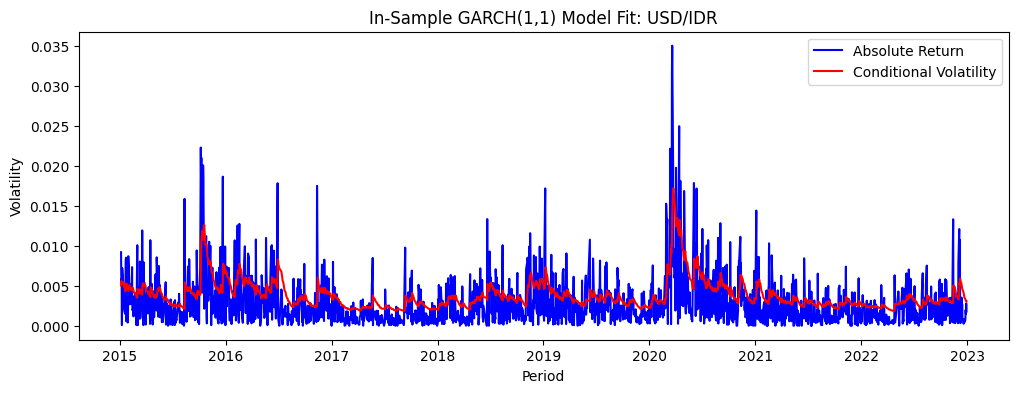

In [136]:
# In-sample plot
# Tujuannya untuk membandingkan model GARCH dengan data nyata
# Dan melihat apakah GARCH bisa menangkap fluktuasi volatilitas.

# Define realized volatility (abs return) -> data nyata
realized_in_train = np.abs(df_train)

# Volatility outputs from GARCH estimation/fitting -> must be the same as the period of the train set
vol_train = pd.Series(volatility_train.values, index=df_train.index)
df_train.index = pd.to_datetime(df_train.index)

# Plot
plt.figure(figsize=(12,4))
plt.plot(realized_in_train, label='Absolute Return', color="blue")
plt.plot(vol_train, label='Conditional Volatility', color="red")
plt.title('In-Sample GARCH(1,1) Model Fit: USD/IDR')
plt.xlabel('Period')
plt.ylabel('Volatility')
plt.legend()

# format x-axis untuk tanggal
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.show()

In [99]:
# Volatility (Test set)

# Menggunakan model GARCH yang sudah difit untuk forecast test set
# Forecast yang digunakan adalah multi-forecast -> karena volatility digunakan sebagai fitur tambahan utk LSTM
# Bukan utk evaluasi performa GARCH model, sehingga rolling forecast tidak digunakan di sini
forecast = res_in.forecast(horizon=len(df_test), reindex=False)

# GARCH menghasilkan conditional variance (σ²_t)
variance = forecast.variance.values[-1, :]

# Sementara volatility diperoleh dari akar kuadrat variance
# Langsung diinsert ke dalam dataframe
volatility_test = pd.DataFrame(np.sqrt(variance))
volatility_test.columns = ['cond_vol']
volatility_test.index = pd.to_datetime(df_test.index)

volatility_test.head()

,cond_vol
period,
2023-01-02,0.002968
2023-01-03,0.002998
2023-01-04,0.003027
2023-01-05,0.003055
2023-01-06,0.003082


In [173]:
# Insert volatility into the original dataset

# Read df
lstm_df = pd.read_csv("dataset/LSTM/lstm_df.csv")
# Ensure that period is the index
lstm_df['period'] = pd.to_datetime(lstm_df['period'])
lstm_df.set_index('period', inplace=True)

# Insert realized volatility
realized_in_test = np.abs(df_test)
lstm_df.loc[realized_in_train.index, 'realized_return'] = realized_in_train['idr_usd']
lstm_df.loc[realized_in_test.index, 'realized_return'] = realized_in_test['idr_usd']

# Insert conditional volatility from GARCH
lstm_df.loc[volatility_train.index, 'cond_vol'] = volatility_train
lstm_df.loc[volatility_test.index, 'cond_vol'] = volatility_test

lstm_df = lstm_df.dropna()
lstm_df.head()

,idr_usd,inflation_rate,interest_rate,realized_return,cond_vol
period,,,,,
2015-01-05,12652.0,6.96,7.75,0.009211,0.005032
2015-01-06,12721.0,6.96,7.75,0.005439,0.005578
2015-01-07,12796.0,6.96,7.75,0.005878,0.005540
2015-01-08,12795.0,6.96,7.75,0.000078,0.005552
2015-01-09,12703.0,6.96,7.75,0.007216,0.005242


In [174]:
lstm_df.tail()

,idr_usd,inflation_rate,interest_rate,realized_return,cond_vol
period,,,,,
2024-12-23,16351.35,1.57,6.0,0.000430,0.004207
2024-12-24,16239.80,1.57,6.0,0.006845,0.004207
2024-12-27,16289.04,1.57,6.0,0.003027,0.004207
2024-12-30,16332.25,1.57,6.0,0.002649,0.004207
2024-12-31,16242.81,1.57,6.0,0.005491,0.004207


In [175]:
lstm_df.to_csv('dataset/LSTM/lstm_df_train_val.csv')

## Save Model

In [ ]:
import pickle

# Save GARCH model
with open('garch_model.pkl', 'wb') as f:
    pickle.dump(res_in, f)
    print("Model has been saved sucessfully!")